# 🤖 ¿Puede una Máquina Reconocer un Rostro?
## Álgebra Lineal en IA: Transformaciones Lineales y Valores Propios
---
**Actividad Computacional — Álgebra Lineal** | **Modalidad:** Parejas | **Duración:** 2 horas

**Nombres:** _____________________________ y _____________________________  
**Fecha:** _______________

---
### 📋 Instrucciones Generales

Este cuaderno es su espacio de exploración. Los bloques de código **ya están escritos** — su tarea es:

1. **Ejecutar** cada celda de código en orden (`Shift + Enter`)
2. **Observar** cuidadosamente los resultados y visualizaciones
3. **Responder** las preguntas en las celdas marcadas con ✏️
4. **Discutir** con su compañero antes de escribir — las mejores respuestas muestran razonamiento conjunto

> ⚠️ **No modifiquen el código**. Si algo falla, llamen al profesor.

---
### 🎯 Objetivos

Al finalizar esta actividad serán capaces de:
- Interpretar imágenes digitales como vectores en espacios de alta dimensión
- Identificar transformaciones matriciales concretas como transformaciones lineales
- Explicar qué representan los **valores y vectores propios** de la matriz de covarianza
- Conectar la descomposición espectral con los **Eigenfaces** usados en visión por computadora
- Evaluar cuánta información captura cada componente principal y sus implicaciones

---
### 📌 Contexto

El reconocimiento facial es una de las aplicaciones más icónicas de la IA. Desde desbloquear tu teléfono hasta sistemas de vigilancia en aeropuertos, los algoritmos detrás de esta tecnología se apoyan en su núcleo más fundamental en dos conceptos que ya conocen: **transformaciones lineales** y **valores propios**.

En esta actividad trabajarán con el **dataset Olivetti Faces** — una colección real de 400 fotografías de 40 personas distintas, capturadas en AT&T Laboratories Cambridge entre 1992 y 1994. ¡Prepárense para ver álgebra lineal en acción!

In [17]:
# ══════════════════════════════════════════════════════════════
#  CONFIGURACIÓN — Ejecuten esta celda PRIMERO (puede tardar ~10 s)
# ══════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import affine_transform
from sklearn.datasets import fetch_olivetti_faces
import warnings
warnings.filterwarnings('ignore')

# Parámetros visuales globales
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

print("✅ Librerías cargadas correctamente")
print(f"   NumPy      {np.__version__}")
print(f"   Matplotlib {plt.matplotlib.__version__}")

✅ Librerías cargadas correctamente
   NumPy      2.2.3
   Matplotlib 3.10.0


---
## 📸 Sección 1 — Las Imágenes como Vectores

Cada imagen de $64 \times 64$ píxeles puede interpretarse como un **vector en $\mathbb{R}^{4096}$**: simplemente "desenrollamos" la matriz de píxeles fila por fila formando un vector de 4096 componentes.

La **matriz de datos $X$** tiene dimensiones $400 \times 4096$, donde:
- Cada **fila** es una imagen (un punto en $\mathbb{R}^{4096}$)
- Cada **columna** corresponde a la intensidad de un píxel específico en todas las imágenes

Carguemos el dataset y exploremos su estructura.

In [18]:
# ══════════════════════════════════════════════════════════════
#  CARGA DE DATOS — Dataset Olivetti Faces
# ══════════════════════════════════════════════════════════════
print("⏳ Descargando dataset Olivetti Faces (primera vez puede tardar ~30 s)...")
dataset  = fetch_olivetti_faces(shuffle=True, random_state=42)

faces    = dataset.data    # Matriz: 400 × 4096  (cada fila = imagen "aplanada")
images   = dataset.images  # Tensor:  400 × 64 × 64
labels   = dataset.target  # Etiquetas: 0‒39  (id de la persona)

n_samples, n_features = faces.shape
n_side = 64  # imágenes cuadradas de 64×64

print(f"\n📊 Información del dataset:")
print(f"   Número de imágenes      : {n_samples}")
print(f"   Dimensión del vector    : {n_features}  (= {n_side} × {n_side} píxeles)")
print(f"   Número de personas      : {len(np.unique(labels))}")
print(f"   Imágenes por persona    : {n_samples // len(np.unique(labels))}")
print(f"\n   Forma de la matriz X    : {faces.shape}")
print(f"   Tipo de datos           : {faces.dtype}")
print(f"   Rango de valores        : [{faces.min():.3f}, {faces.max():.3f}]")

⏳ Descargando dataset Olivetti Faces (primera vez puede tardar ~30 s)...

📊 Información del dataset:
   Número de imágenes      : 400
   Dimensión del vector    : 4096  (= 64 × 64 píxeles)
   Número de personas      : 40
   Imágenes por persona    : 10

   Forma de la matriz X    : (400, 4096)
   Tipo de datos           : float32
   Rango de valores        : [0.000, 1.000]


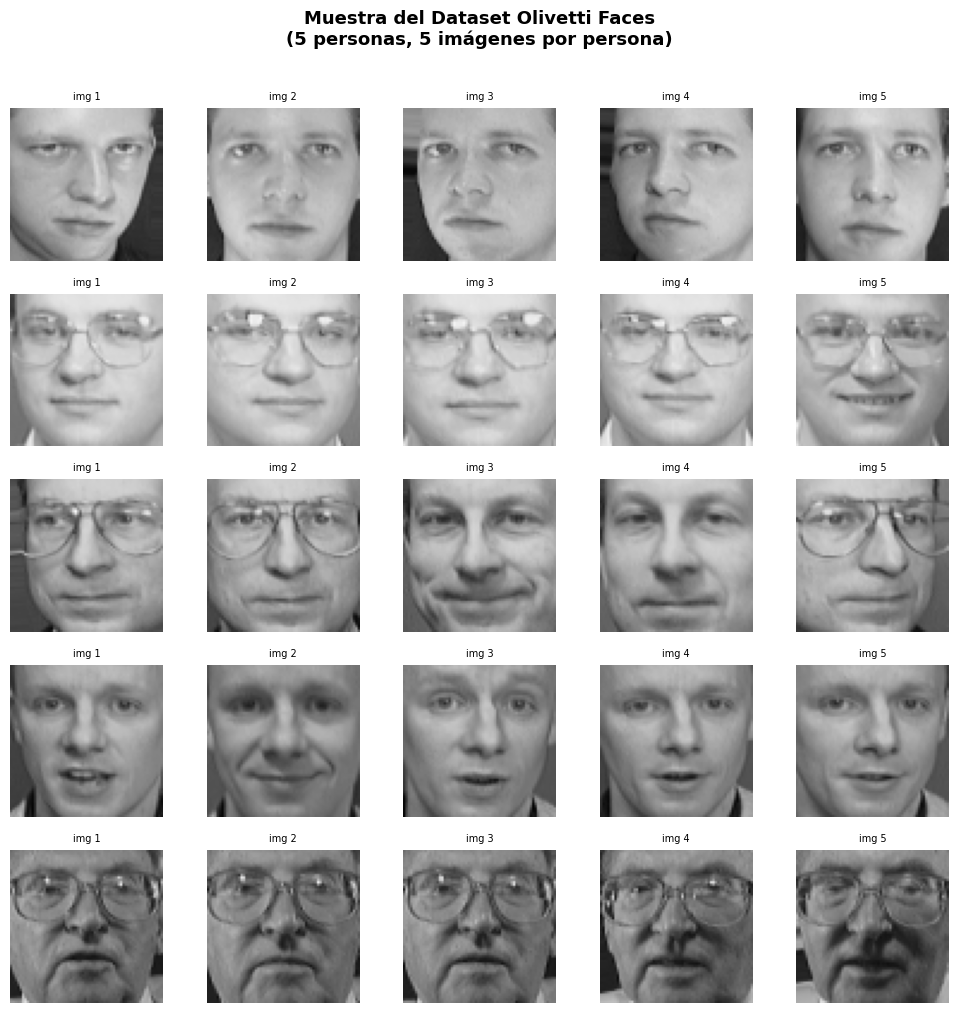


🔬 La imagen de arriba-izquierda como vector (primeros 20 valores):
   [0.38  0.442 0.483 0.545 0.583 0.628 0.649 0.678 0.69  0.711 0.727 0.748
 0.76  0.76  0.769 0.781 0.781 0.798 0.764 0.798]

   → Este vector tiene 4096 componentes (= 64×64 píxeles)


In [19]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZACIÓN — Muestra del dataset: 5 personas × 5 poses
# ══════════════════════════════════════════════════════════════
personas_muestra = [0, 5, 12, 20, 33]  # 5 personas al azar

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle("Muestra del Dataset Olivetti Faces\n(5 personas, 5 imágenes por persona)",
             fontsize=13, fontweight='bold', y=1.01)

for fila, pid in enumerate(personas_muestra):
    imgs_pid = np.where(labels == pid)[0]
    for col in range(5):
        ax = axes[fila, col]
        ax.imshow(images[imgs_pid[col]], cmap='gray', vmin=0, vmax=1)
        if col == 0:
            ax.set_ylabel(f"Persona {pid}", fontsize=9, fontweight='bold')
        ax.set_title(f"img {col+1}", fontsize=7)
        ax.axis('off')

plt.tight_layout()
plt.show()

# Mostrar también la "huella digital" vectorial de una imagen
print("\n🔬 La imagen de arriba-izquierda como vector (primeros 20 valores):")
print(f"   {faces[np.where(labels==0)[0][0], :20].round(3)}")
print(f"\n   → Este vector tiene {n_features} componentes (= {n_side}×{n_side} píxeles)")

### ✏️ Preguntas 1 — Espacio Vectorial de Imágenes

**P1.1** La matriz `X` tiene forma $(400, 4096)$. Cada imagen es un punto en $\mathbb{R}^{4096}$. ¿El conjunto de las 400 imágenes de rostros forma un **subespacio vectorial** de $\mathbb{R}^{4096}$? Verifiquen las condiciones de la definición (cerradura bajo suma y bajo producto escalar).

> *Respuesta:*

---

**P1.2** El espacio $\mathbb{R}^{4096}$ tiene dimensión 4096 y contiene todas las imágenes de $64\times64$ posibles (ruido, paisajes, rostros, etc.). Sin embargo, las imágenes de rostros humanos están **concentradas en una región muy pequeña** de ese espacio. ¿Por qué? ¿Qué implica esto sobre el rango efectivo de la matriz $X$?

> *Respuesta:*

---

**P1.3** La distancia entre dos imágenes (vectores $\mathbf{x}_1, \mathbf{x}_2 \in \mathbb{R}^{4096}$) se mide como $\|\mathbf{x}_1 - \mathbf{x}_2\|_2$. ¿Es esta una métrica matemáticamente válida? ¿Qué significa perceptualmente que dos imágenes estén "cerca" en esta métrica? ¿Tiene limitaciones esta forma de medir similitud entre rostros?

> *Respuesta:*

---
## 🔄 Sección 2 — Transformaciones Lineales sobre Imágenes

Una **transformación lineal** $T: \mathbb{R}^n \to \mathbb{R}^m$ se puede representar como $T(\mathbf{x}) = A\mathbf{x}$, con $A \in \mathbb{R}^{m\times n}$.

Para imágenes 2D, las transformaciones geométricas clásicas (rotación, escala, cizalla, reflexión) actúan sobre las **coordenadas de los píxeles** como matrices $2\times 2$. Exploremos cada una y observemos sus efectos sobre un rostro real.

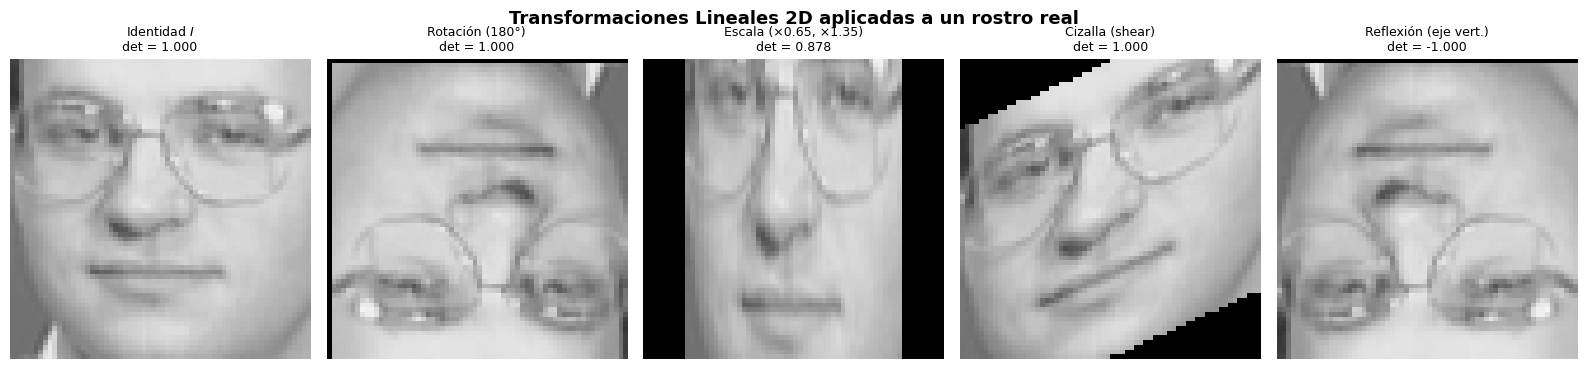

In [30]:
# ══════════════════════════════════════════════════════════════
#  TRANSFORMACIONES LINEALES — matrices 2×2 sobre coordenadas
# ══════════════════════════════════════════════════════════════

# Imagen de referencia (persona 5, primera imagen disponible)
ref_idx = np.where(labels == 5)[0][0]
img_ref = images[ref_idx].copy()   # 64×64

def aplicar_transformacion_2d(imagen, A):
    """Aplica la transformación lineal 2D 'A' a una imagen (alrededor de su centro)."""
    centro = np.array(imagen.shape) / 2.0
    offset = centro - A @ centro
    return affine_transform(imagen, A, offset=offset, mode='constant', cval=0.0)

# ── Definición de matrices ──────────────────────────────────────────────────────
# Rotación de 180°: cos(180°)=-1, sin(180°)=0  →  eigenvalores reales λ=-1,-1
T_id  = np.eye(2)
T_rot = np.array([[-1.0,  0.0],
                  [ 0.0, -1.0]])   # rotación 180° = reflexión en el origen
T_esc = np.array([[0.65, 0.0 ],
                  [0.0,  1.35]])
T_ciz = np.array([[1.0,  0.45],
                  [0.0,  1.0 ]])
T_ref = np.array([[-1.0, 0.0 ],
                  [ 0.0, 1.0 ]])

transformaciones = {
    "Identidad $I$":          T_id,
    "Rotación (180°)":        T_rot,
    "Escala (×0.65, ×1.35)":  T_esc,
    "Cizalla (shear)":        T_ciz,
    "Reflexión (eje vert.)":  T_ref,
}

# ── Visualización ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 3.8))
fig.suptitle("Transformaciones Lineales 2D aplicadas a un rostro real",
             fontsize=13, fontweight='bold')

for ax, (nombre, A) in zip(axes, transformaciones.items()):
    img_t = aplicar_transformacion_2d(img_ref, A)
    ax.imshow(img_t, cmap='gray', vmin=0, vmax=1)
    det = np.linalg.det(A)
    ax.set_title(f"{nombre}\ndet = {det:.3f}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [31]:
# ══════════════════════════════════════════════════════════════
#  EIGENVALORES DE LAS MATRICES DE TRANSFORMACIÓN
# ══════════════════════════════════════════════════════════════
print(f"{'Transformación':<30} {'det(A)':>8}  {'λ₁':>10}  {'λ₂':>10}  {'|λ₁|':>7}  {'|λ₂|':>7}  {'traza':>7}")
print("─" * 85)

for nombre, A in transformaciones.items():
    vals = np.linalg.eigvals(A)
    det  = np.linalg.det(A)
    tr   = np.trace(A)
    nombre_limpio = nombre.replace('$', '').replace('\\', '')
    # Todos los eigenvalores son reales en estas transformaciones
    v1, v2 = vals[0].real, vals[1].real
    print(f"{nombre_limpio:<30} {det:>8.4f}  {v1:>+10.4f}  {v2:>+10.4f}  {abs(v1):>7.4f}  {abs(v2):>7.4f}  {tr:>7.4f}")

print()
print("💡 Relaciones clave:  det(A) = λ₁ · λ₂   |   traza(A) = λ₁ + λ₂")
print()
print("⚠️  Nota conceptual: una rotación por ángulo θ ≠ 0°, 180° genera eigenvalores")
print("   COMPLEJOS λ = e^{±iθ}, porque ningún vector real queda invariante en dirección.")
print("   Solo θ = 0° (identidad) y θ = 180° (usada aquí) producen eigenvalores reales.")

Transformación                   det(A)          λ₁          λ₂     |λ₁|     |λ₂|    traza
─────────────────────────────────────────────────────────────────────────────────────
Identidad I                      1.0000     +1.0000     +1.0000   1.0000   1.0000   2.0000
Rotación (180°)                  1.0000     -1.0000     -1.0000   1.0000   1.0000  -2.0000
Escala (×0.65, ×1.35)            0.8775     +0.6500     +1.3500   0.6500   1.3500   2.0000
Cizalla (shear)                  1.0000     +1.0000     +1.0000   1.0000   1.0000   2.0000
Reflexión (eje vert.)           -1.0000     -1.0000     +1.0000   1.0000   1.0000   0.0000

💡 Relaciones clave:  det(A) = λ₁ · λ₂   |   traza(A) = λ₁ + λ₂

⚠️  Nota conceptual: una rotación por ángulo θ ≠ 0°, 180° genera eigenvalores
   COMPLEJOS λ = e^{±iθ}, porque ningún vector real queda invariante en dirección.
   Solo θ = 0° (identidad) y θ = 180° (usada aquí) producen eigenvalores reales.


### ✏️ Preguntas 2 — Transformaciones Lineales y sus Eigenvalores

**P2.1** Completen la tabla basándose en los resultados anteriores:

| Transformación | $\det(A)$ | $\text{traza}(A)$ | $\lambda_1,\, \lambda_2$ | ¿Preserva orientación? | ¿Cambia áreas? |
|---|:---:|:---:|:---:|:---:|:---:|
| Identidad | | | | | |
| Rotación 180° | | | | | |
| Escala (×0.65, ×1.35) | | | | | |
| Cizalla | | | | | |
| Reflexión | | | | | |

*¿Qué relación general observan entre $\det(A)$, $\text{traza}(A)$ y los eigenvalores?*

> *Respuesta:*

---

**P2.2** La rotación de 180° tiene $\lambda_1 = \lambda_2 = -1$.

a) Dado que $\lambda_1 = \lambda_2 = -1$, la matriz es $A = -I$. ¿Todo vector $\mathbf{v} \neq \mathbf{0}$ es eigenvector? Justifiquen algebraicamente y descríbanlo geométricamente: ¿qué le ocurre a cada dirección bajo esta transformación?

b) Una rotación por ángulo $\theta \neq 0°, 180°$ **no tiene eigenvectores reales** porque sus eigenvalores son complejos ($\lambda = e^{\pm i\theta}$). Sin calcularlos, ¿por qué tiene sentido geométricamente esta ausencia? ¿Puede una rotación de 30° dejar algún vector apuntando en la misma dirección que antes?

> *Respuesta:*

---

**P2.3** La reflexión sobre el eje vertical tiene eigenvalores $\lambda_1 = -1$ y $\lambda_2 = 1$.  
a) Encuentren los eigenvectores correspondientes a cada eigenvalor.  
b) Interpreten geométricamente: ¿qué le ocurre a cada dirección propia bajo la reflexión?  
c) ¿Qué representan esas dos direcciones en el contexto de la imagen de un rostro?

> *Respuesta:*

---

**P2.4** La cizalla tiene ambos eigenvalores iguales a $\lambda = 1$, sin embargo **no es la identidad**. ¿Cómo es posible? ¿Es la cizalla diagonalizable? Expliquen qué tipo de matriz es y qué implica esto sobre su estructura algebraica.

> *Respuesta:*

---
## 📊 Sección 3 — La Matriz de Covarianza y el Teorema Espectral

Tenemos 400 imágenes en $\mathbb{R}^{4096}$. Queremos encontrar las **direcciones de mayor variación** del conjunto: las orientaciones a lo largo de las cuales los rostros difieren más entre sí.

Esto nos lleva a la **matriz de covarianza** de los datos centrados $\tilde{X} = X - \bar{x}\mathbf{1}^T$:

$$C = \frac{1}{n-1}\,\tilde{X}^T\tilde{X} \quad \in \mathbb{R}^{4096 \times 4096}$$

$C$ es **simétrica y semidefinida positiva**. Por el **Teorema Espectral**, sus eigenvalores son reales y no negativos, y sus eigenvectores son ortonormales — estas propiedades son la clave de todo lo que sigue.

> **Nota técnica:** $C$ es $4096\times4096$ y sería muy costosa de calcular directamente. Usamos la **descomposición SVD** de $\tilde{X}$, que entrega los mismos eigenvectores de forma eficiente.

📐 Verificación del centrado:
   Media de X          (primeros 5): [0.4   0.434 0.476 0.518 0.555]
   Media de X_centrado (primeros 5): [-8.81e-08 -6.22e-08  1.22e-07  9.43e-08 -5.65e-08]

   ¿Es X_centrado de media cero? True
   (Los valores ~1e-8 son error de punto flotante — matemáticamente son cero)


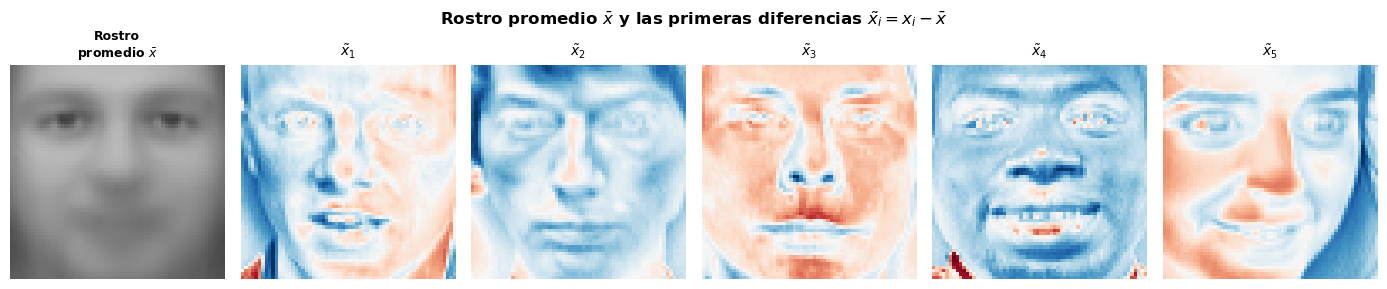


💡 Las imágenes de diferencia (azul=negativo, rojo=positivo) muestran
   en qué zonas cada persona difiere del 'rostro típico'.


In [21]:
# ══════════════════════════════════════════════════════════════
#  PASO 1 — CENTRADO DE DATOS y ROSTRO PROMEDIO
# ══════════════════════════════════════════════════════════════
X             = faces.copy()                         # 400 × 4096
media_facial  = X.mean(axis=0)                       # vector promedio (4096,)
X_centrado    = X - media_facial                     # ˜X

# ── Verificación numérica ───────────────────────────────────────────────────────
print("📐 Verificación del centrado:")
print(f"   Media de X          (primeros 5): {X.mean(axis=0)[:5].round(3)}")
print(f"   Media de X_centrado (primeros 5): {X_centrado.mean(axis=0)[:5].round(10)}")
# Tolerancia 1e-6: errores de punto flotante (~1e-8) son esencialmente cero
print(f"\n   ¿Es X_centrado de media cero? {np.allclose(X_centrado.mean(axis=0), 0, atol=1e-6)}")
print(f"   (Los valores ~1e-8 son error de punto flotante — matemáticamente son cero)")

# ── Visualización: rostro promedio ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
fig.suptitle("Rostro promedio $\\bar{x}$ y las primeras diferencias $\\tilde{x}_i = x_i - \\bar{x}$",
             fontsize=12, fontweight='bold')

axes[0].imshow(media_facial.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Rostro\npromedio $\\bar{x}$", fontsize=9, fontweight='bold')
axes[0].axis('off')

for i in range(5):
    diff = X_centrado[i].reshape(64, 64)
    vmax = np.abs(diff).max()
    axes[i+1].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[i+1].set_title(f"$\\tilde{{x}}_{{{i+1}}}$", fontsize=10)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print("\n💡 Las imágenes de diferencia (azul=negativo, rojo=positivo) muestran")
print("   en qué zonas cada persona difiere del 'rostro típico'.")

In [22]:
# ══════════════════════════════════════════════════════════════
#  PASO 2 — SVD y EIGENDESCOMPOSICIÓN DE C
# ══════════════════════════════════════════════════════════════
print("⏳ Calculando SVD de X_centrado (puede tardar ~5 s)...")

# SVD:  X_centrado = U · diag(s) · Vt
#   → eigenvectores de C  = filas de Vt
#   → eigenvalores  de C  = s² / (n-1)
U, s, Vt = np.linalg.svd(X_centrado, full_matrices=False)

eigenvalores   = s**2 / (n_samples - 1)   # decrecientes
eigenvectores  = Vt                         # filas = eigenvectores ortonormales

print(f"\n✅ SVD completada")
print(f"   Forma de U  : {U.shape}   (coeficientes de proyección)")
print(f"   Forma de s  : {s.shape}   (valores singulares)")
print(f"   Forma de Vt : {Vt.shape}  (eigenvectores = filas)")

print(f"\n📊 Primeros 5 eigenvalores de C:")
for i in range(5):
    print(f"   λ_{i+1} = {eigenvalores[i]:.4f}  ({eigenvalores[i]/eigenvalores.sum()*100:.2f}% de la varianza total)")

# Comparación con varianza muestral (ddof=1, divide por n-1)
varianza_muestral = np.var(X_centrado, axis=0, ddof=1).sum()
print(f"\n   Varianza total = traza(C) = Σλᵢ = {eigenvalores.sum():.4f}")
print(f"   Var. muestral (ddof=1)       = {varianza_muestral:.4f}")
print(f"   ¿Son iguales? {np.isclose(eigenvalores.sum(), varianza_muestral, rtol=1e-4)}")

# ── Verificar ortonormalidad de los primeros eigenvectores ──────────────────────
print(f"\n🔬 Verificación de ortonormalidad de los eigenvectores:")
VkVkt = eigenvectores[:5] @ eigenvectores[:5].T
print(f"   V₅ · V₅ᵀ  (debe ser I₅):")
print(np.round(VkVkt, 6))

⏳ Calculando SVD de X_centrado (puede tardar ~5 s)...

✅ SVD completada
   Forma de U  : (400, 400)   (coeficientes de proyección)
   Forma de s  : (400,)   (valores singulares)
   Forma de Vt : (400, 4096)  (eigenvectores = filas)

📊 Primeros 5 eigenvalores de C:
   λ_1 = 18.8402  (23.81% de la varianza total)
   λ_2 = 11.0718  (13.99% de la varianza total)
   λ_3 = 6.3046  (7.97% de la varianza total)
   λ_4 = 3.9546  (5.00% de la varianza total)
   λ_5 = 2.8560  (3.61% de la varianza total)

   Varianza total = traza(C) = Σλᵢ = 79.1181
   Var. muestral (ddof=1)       = 79.1181
   ¿Son iguales? True

🔬 Verificación de ortonormalidad de los eigenvectores:
   V₅ · V₅ᵀ  (debe ser I₅):
[[ 1. -0.  0.  0.  0.]
 [-0.  1. -0.  0. -0.]
 [ 0. -0.  1.  0.  0.]
 [ 0.  0.  0.  1. -0.]
 [ 0. -0.  0. -0.  1.]]


---
## 👻 Sección 4 — Eigenfaces: Los "Rostros Fantasma"

Los **Eigenfaces** son simplemente los eigenvectores de la matriz de covarianza $C$, visualizados como imágenes de $64\times64$. Cada eigenface captura un **patrón de variación** en los rostros, ordenado de mayor a menor importancia según su eigenvalor.

La transformación lineal $T: \mathbb{R}^{4096} \to \mathbb{R}^k$ que proyecta una imagen sobre los $k$ primeros eigenfaces es:

$$\boldsymbol{\alpha} = V_k \,\tilde{\mathbf{x}} \quad \in \mathbb{R}^k$$

donde las **filas** de $V_k \in \mathbb{R}^{k\times4096}$ son los $k$ primeros eigenvectores. Este es el corazón de la reducción dimensional.

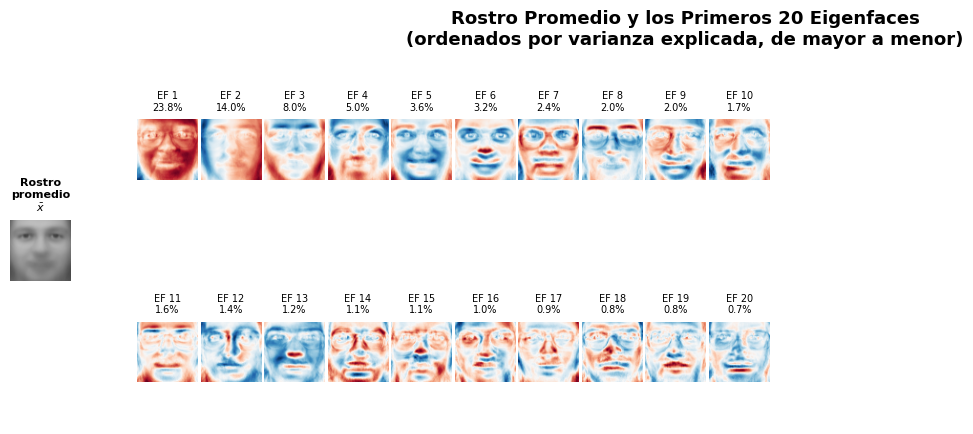

In [23]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZACIÓN — Rostro promedio + primeros 20 Eigenfaces
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 4.5))
fig.suptitle("Rostro Promedio y los Primeros 20 Eigenfaces\n"
             "(ordenados por varianza explicada, de mayor a menor)",
             fontsize=13, fontweight='bold', y=1.03)

gs = gridspec.GridSpec(2, 22, figure=fig, wspace=0.05, hspace=0.4)

# Rostro promedio
ax_m = fig.add_subplot(gs[:, 0])
ax_m.imshow(media_facial.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
ax_m.set_title("Rostro\npromedio\n$\\bar{x}$", fontsize=8, fontweight='bold')
ax_m.axis('off')

# Separador (columna vacía)
fig.add_subplot(gs[:, 1]).axis('off')

# 20 eigenfaces
varianza_total = eigenvalores.sum()
for i in range(20):
    row, col = divmod(i, 10)
    ax = fig.add_subplot(gs[row, col + 2])
    ef = eigenvectores[i].reshape(64, 64)
    ef_norm = (ef - ef.min()) / (ef.max() - ef.min() + 1e-8)
    ax.imshow(ef_norm, cmap='RdBu_r')
    pct = eigenvalores[i] / varianza_total * 100
    ax.set_title(f"EF {i+1}\n{pct:.1f}%", fontsize=7)
    ax.axis('off')

plt.show()

📊 ¿Cuántos eigenfaces necesito para capturar X% de la varianza?
  Umbral |  k mínimo |  Reducción dim. |   k / 4096
───────────────────────────────────────────────────────
     50% |         4 |           99.9% |      0.10%
     75% |        19 |           99.5% |      0.46%
     90% |        66 |           98.4% |      1.61%
     95% |       123 |           97.0% |      3.00%
     99% |       260 |           93.7% |      6.35%


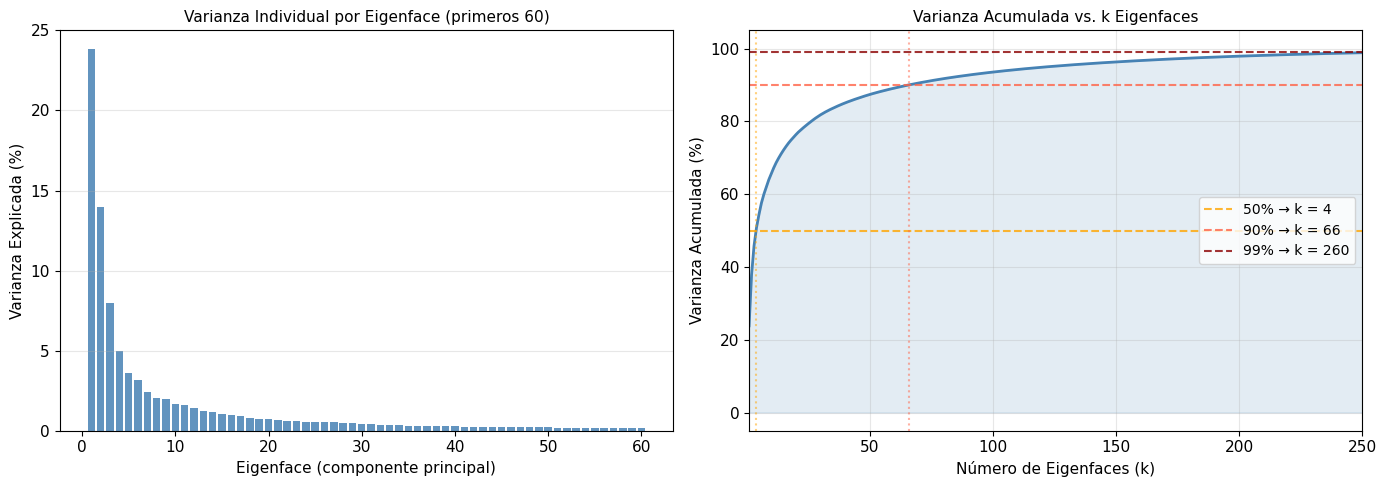

In [24]:
# ══════════════════════════════════════════════════════════════
#  ESPECTRO DE EIGENVALORES — Varianza individual y acumulada
# ══════════════════════════════════════════════════════════════
var_acum = np.cumsum(eigenvalores) / varianza_total * 100
var_ind  = eigenvalores / varianza_total * 100

# Umbrales clave
print("📊 ¿Cuántos eigenfaces necesito para capturar X% de la varianza?")
print(f"{'Umbral':>8} | {'k mínimo':>9} | {'Reducción dim.':>15} | {'k / 4096':>10}")
print("─" * 55)
for umbral in [50, 75, 90, 95, 99]:
    k_u = int(np.argmax(var_acum >= umbral)) + 1
    reduccion = (1 - k_u / n_features) * 100
    print(f"{umbral:>7}% | {k_u:>9} | {reduccion:>14.1f}% | {k_u/n_features*100:>9.2f}%")

# ── Gráficas ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: varianza individual (primeros 60)
k_show = 60
axes[0].bar(range(1, k_show+1), var_ind[:k_show], color='steelblue', alpha=0.85)
axes[0].set_xlabel("Eigenface (componente principal)")
axes[0].set_ylabel("Varianza Explicada (%)")
axes[0].set_title(f"Varianza Individual por Eigenface (primeros {k_show})")
axes[0].grid(axis='y', alpha=0.3)

# Derecha: varianza acumulada
ks = np.arange(1, len(eigenvalores) + 1)
axes[1].plot(ks, var_acum, 'steelblue', linewidth=2)
axes[1].fill_between(ks, var_acum, alpha=0.15, color='steelblue')

colores = ['orange', 'tomato', 'darkred']
for umbral, color in zip([50, 90, 99], colores):
    k_u = int(np.argmax(var_acum >= umbral)) + 1
    axes[1].axhline(y=umbral, color=color, linestyle='--', alpha=0.8,
                    label=f'{umbral}% → k = {k_u}')
    axes[1].axvline(x=k_u,   color=color, linestyle=':', alpha=0.5)

axes[1].set_xlabel("Número de Eigenfaces (k)")
axes[1].set_ylabel("Varianza Acumulada (%)")
axes[1].set_title("Varianza Acumulada vs. k Eigenfaces")
axes[1].legend(fontsize=10)
axes[1].set_xlim(1, 250)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ✏️ Preguntas 3 — Covarianza, Eigenfaces y Espectro

**P3.1** ¿Por qué es necesario **centrar los datos** (restar $\bar{x}$) antes de calcular la matriz de covarianza? ¿Qué información se pierde si no centramos? Piensen en qué mediría $\tilde{X}^T\tilde{X}$ versus $X^TX$.

> *Respuesta:*

---

**P3.2** Enuncien el **Teorema Espectral** para matrices simétricas y expliquen **cada una** de sus consecuencias en este contexto:

| Consecuencia del Teorema Espectral | Significado en eigenfaces |
|---|---|
| Los eigenvalores son reales | |
| Los eigenvectores son ortogonales | |
| $C$ es diagonalizable como $C = V\Lambda V^T$ | |
| Los eigenvalores son $\geq 0$ (semidefinida positiva) | |

---

**P3.3** Observen los primeros eigenfaces visualmente. Cada uno captura un "patrón de variación". Describan qué parece capturar cada uno:

| Eigenface | % Varianza | ¿Qué patrón visual captura? (iluminación, orientación, rasgos, ...) |
|---|---|---|
| EF 1 | | |
| EF 2 | | |
| EF 3 | | |
| EF 4 | | |

---

**P3.4** El primer eigenface maximiza la varianza proyectada. Esto se puede plantear como el problema de optimización:

$$\max_{\|\mathbf{v}\|=1} \mathbf{v}^T C\, \mathbf{v}$$

a) ¿Cuál es la solución a este problema? (enúncienla formalmente)  
b) Si $\mathbf{v}_1$ es la solución, ¿cuál es el valor máximo alcanzado? ¿En qué término lo reconocen?

> *Respuesta:*

---

**P3.5** Según la tabla y gráfica de varianza acumulada:  
a) ¿Cuántos eigenfaces capturan el 90% de la varianza? ¿Cuánto representa eso del espacio original de 4096 dimensiones?  
b) La curva de varianza acumulada tiene una "rodilla" (codo). ¿Qué significado práctico tiene elegir $k$ en esa zona?

> *Respuesta:*

---
## 🖼️ Sección 5 — Reconstrucción: La Magia de los k Eigenfaces

Dado un rostro $\mathbf{x}$, podemos **proyectarlo** sobre el subespacio generado por los $k$ primeros eigenfaces y **reconstruirlo**:

$$\hat{\mathbf{x}} = \bar{\mathbf{x}} + \sum_{i=1}^{k} \langle \tilde{\mathbf{x}},\, \mathbf{v}_i \rangle \, \mathbf{v}_i = \bar{\mathbf{x}} + V_k^T(V_k\,\tilde{\mathbf{x}})$$

Con pocos eigenfaces ($k$ pequeño) la reconstrucción será borrosa. Con más eigenfaces, mejora — pero nunca puede **empeorar** al agregar más.

> ¿Por qué? Esto tiene una justificación matemática profunda que explorarán en las preguntas.

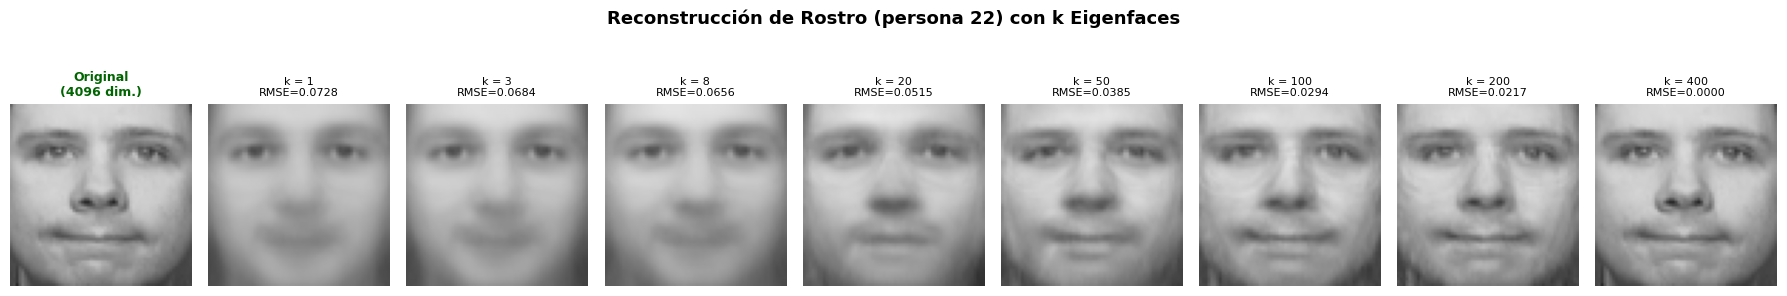

In [25]:
# ══════════════════════════════════════════════════════════════
#  RECONSTRUCCIÓN VISUAL con distintos k
# ══════════════════════════════════════════════════════════════
persona_id = 22
idx_img    = np.where(labels == persona_id)[0][3]   # 4ª imagen de la persona 22

img_orig     = faces[idx_img]                       # vector original (4096,)
img_centrada = img_orig - media_facial

ks_demo = [1, 3, 8, 20, 50, 100, 200, 400]

fig, axes = plt.subplots(1, len(ks_demo) + 1, figsize=(18, 3.5))
fig.suptitle(f"Reconstrucción de Rostro (persona {persona_id}) con k Eigenfaces",
             fontsize=13, fontweight='bold')

# Original
axes[0].imshow(img_orig.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original\n(4096 dim.)", fontsize=9, fontweight='bold', color='darkgreen')
axes[0].axis('off')

errores_demo = []
for i, k in enumerate(ks_demo):
    Vk       = eigenvectores[:k]                      # k × 4096
    coef     = img_centrada @ Vk.T                    # proyección: k coeficientes
    rec_cen  = coef @ Vk                              # reconstrucción centrada
    rec      = np.clip(rec_cen + media_facial, 0, 1)  # añadir media, recortar

    rmse = np.sqrt(np.mean((img_orig - rec)**2))
    errores_demo.append(rmse)

    axes[i+1].imshow(rec.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
    axes[i+1].set_title(f"k = {k}\nRMSE={rmse:.4f}", fontsize=8)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

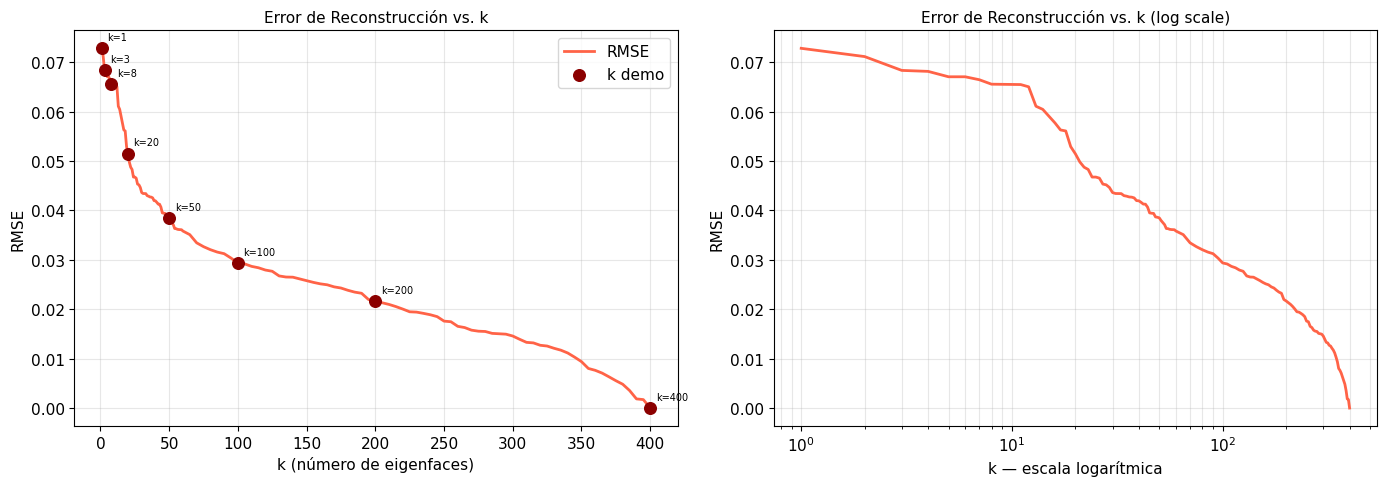


    k |     RMSE | Var. acum. (%)
───────────────────────────────────
    1 |  0.07284 |         23.81%
    3 |  0.06837 |         45.78%
    8 |  0.06558 |         62.00%
   20 |  0.05148 |         76.34%
   50 |  0.03851 |         87.38%
  100 |  0.02938 |         93.54%
  200 |  0.02168 |         97.91%
  400 |  0.00000 |        100.00%


In [26]:
# ══════════════════════════════════════════════════════════════
#  CURVA DE ERROR DE RECONSTRUCCIÓN — RMSE vs k
# ══════════════════════════════════════════════════════════════
ks_dense = list(range(1, 60)) + list(range(60, 401, 5))
errores_curva = []

for k in ks_dense:
    Vk      = eigenvectores[:k]
    coef    = img_centrada @ Vk.T
    rec     = np.clip(coef @ Vk + media_facial, 0, 1)
    errores_curva.append(np.sqrt(np.mean((img_orig - rec)**2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: RMSE vs k (escala lineal)
axes[0].plot(ks_dense, errores_curva, 'tomato', linewidth=2, label='RMSE')
axes[0].scatter(ks_demo, errores_demo, s=70, zorder=5, color='darkred', label='k demo')
for k, e in zip(ks_demo, errores_demo):
    axes[0].annotate(f'k={k}', (k, e), textcoords="offset points", xytext=(4, 6), fontsize=7)
axes[0].set_xlabel("k (número de eigenfaces)")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Error de Reconstrucción vs. k")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Derecha: RMSE vs k (escala logarítmica en x)
axes[1].plot(ks_dense, errores_curva, 'tomato', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel("k — escala logarítmica")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Error de Reconstrucción vs. k (log scale)")
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Tabla de referencia
print(f"\n{'k':>5} | {'RMSE':>8} | {'Var. acum. (%)':>14}")
print("─" * 35)
for k in [1, 3, 8, 20, 50, 100, 200, 400]:
    idx_k = ks_dense.index(k) if k in ks_dense else None
    if idx_k is not None:
        print(f"{k:>5} | {errores_curva[idx_k]:>8.5f} | {var_acum[k-1]:>13.2f}%")

### ✏️ Preguntas 4 — Reconstrucción y Proyección Ortogonal

**P4.1** La reconstrucción con $k$ eigenfaces es una **proyección ortogonal** sobre el subespacio $\text{span}\{\mathbf{v}_1, \ldots, \mathbf{v}_k\}$.

a) Para que la fórmula $\hat{\mathbf{x}} = \bar{\mathbf{x}} + V_k^T(V_k\tilde{\mathbf{x}})$ sea una proyección ortogonal válida, los vectores $\mathbf{v}_i$ deben ser **ortonormales**. Expliquen por qué: ¿qué fallaría algebraicamente si no lo fueran?  
b) Verifiquen en la celda anterior que $V_5 V_5^T = I_5$. ¿Qué propiedad es esa? ¿$V_5$ es cuadrada? ¿Tiene inversa?

> *Respuesta:*

---

**P4.2** Al observar la curva de error:  
a) ¿La función RMSE(k) es **monótonamente decreciente**? ¿Puede RMSE(k) aumentar al pasar de $k$ a $k+1$ eigenfaces? Justifiquen teóricamente (pista: piensen en subespacios anidados $W_k \subset W_{k+1}$).  
b) ¿La caída del error es **lineal** en $k$ o tiene otra forma? ¿Qué implica esto sobre la "utilidad marginal" de agregar más eigenfaces?

> *Respuesta:*

---

**P4.3** Con $k = 100$ eigenfaces, el almacenamiento requerido es:
- Base de eigenfaces: $100 \times 4096$ valores  
- Representación de cada imagen: $100$ coeficientes  
- Vector de media: $4096$ valores  

Calculen el **factor de compresión** para representar las 400 imágenes (original vs comprimido). ¿Es eficiente? ¿Qué se pierde?

> *Respuesta:* *(Cálculo numérico + conclusión)*

---

**P4.4** Predigan (sin ejecutar código): si tomaran una imagen de **ruido blanco aleatorio** (píxeles $\sim \mathcal{U}(0,1)$ independientes) y la reconstruyeran con $k = 50$ eigenfaces, ¿el error de reconstrucción sería mayor, igual, o menor que para un rostro real? Justifiquen usando el concepto de subespacio.

> *Respuesta:*

---
## 🔍 Sección 6 — Verificación de Identidad: ¿Es la misma persona?

Ahora usamos las representaciones en el espacio de eigenfaces para responder una pregunta práctica: **¿son estas dos fotos de la misma persona?**

La idea: si dos rostros corresponden a la misma persona, sus **coeficientes** $\boldsymbol{\alpha} = V_k\tilde{\mathbf{x}}$ deberían ser similares (distancia euclidiana pequeña en $\mathbb{R}^k$). Si son personas distintas, deberían estar más lejos.

Esta es la base de los sistemas de reconocimiento facial por **eigenfaces** (Turk & Pentland, 1991 — uno de los artículos más citados en visión por computadora).

In [28]:
# ══════════════════════════════════════════════════════════════
#  REPRESENTACIONES EN EL ESPACIO DE EIGENFACES
# ══════════════════════════════════════════════════════════════
k_rep = 100                              # dimensión del espacio de representación
Vk    = eigenvectores[:k_rep]            # k_rep × 4096

def representar(imagen):
    """Proyecta una imagen sobre los k_rep primeros eigenfaces."""
    return (imagen - media_facial) @ Vk.T   # vector de k_rep coeficientes

def distancia_ef(img1, img2):
    """Distancia euclidiana en el espacio de eigenfaces."""
    return np.linalg.norm(representar(img1) - representar(img2))

# ── Comparaciones: misma persona ───────────────────────────────────────────────
persona_A = 8
imgs_A = faces[labels == persona_A]

print(f"{'═'*60}")
print(f"  Comparaciones de imágenes de la MISMA persona (ID {persona_A})")
print(f"{'═'*60}")
dist_misma = []
for i in range(len(imgs_A)):
    for j in range(i+1, len(imgs_A)):
        d = distancia_ef(imgs_A[i], imgs_A[j])
        dist_misma.append(d)
        if i < 3 and j < 4:
            print(f"  Imagen {i+1} ↔ Imagen {j+1} : {d:.4f}")

print(f"\n  Promedio   : {np.mean(dist_misma):.4f}")
print(f"  Desv. std. : {np.std(dist_misma):.4f}")
print(f"  Mínimo     : {np.min(dist_misma):.4f}")
print(f"  Máximo     : {np.max(dist_misma):.4f}")

# ── Comparaciones: personas distintas ─────────────────────────────────────────
print(f"\n{'═'*60}")
print("  Comparaciones de imágenes de PERSONAS DISTINTAS")
print(f"{'═'*60}")
pares_test = [(0,1),(2,5),(7,15),(20,33),(11,38)]
dist_distinta = []
for p1, p2 in pares_test:
    img1 = faces[labels == p1][0]
    img2 = faces[labels == p2][0]
    d = distancia_ef(img1, img2)
    dist_distinta.append(d)
    print(f"  Persona {p1:2d} ↔ Persona {p2:2d} : {d:.4f}")

print(f"\n  Promedio   : {np.mean(dist_distinta):.4f}")
print(f"  Desv. std. : {np.std(dist_distinta):.4f}")

════════════════════════════════════════════════════════════
  Comparaciones de imágenes de la MISMA persona (ID 8)
════════════════════════════════════════════════════════════
  Imagen 1 ↔ Imagen 2 : 6.6768
  Imagen 1 ↔ Imagen 3 : 7.5337
  Imagen 1 ↔ Imagen 4 : 5.9094
  Imagen 2 ↔ Imagen 3 : 4.1111
  Imagen 2 ↔ Imagen 4 : 7.7341
  Imagen 3 ↔ Imagen 4 : 5.9882

  Promedio   : 6.3173
  Desv. std. : 1.6821
  Mínimo     : 2.8382
  Máximo     : 10.1932

════════════════════════════════════════════════════════════
  Comparaciones de imágenes de PERSONAS DISTINTAS
════════════════════════════════════════════════════════════
  Persona  0 ↔ Persona  1 : 12.7201
  Persona  2 ↔ Persona  5 : 14.1832
  Persona  7 ↔ Persona 15 : 10.7623
  Persona 20 ↔ Persona 33 : 12.2822
  Persona 11 ↔ Persona 38 : 13.4061

  Promedio   : 12.6708
  Desv. std. : 1.1510


⏳ Calculando distancias para todos los pares (puede tardar ~15 s)...


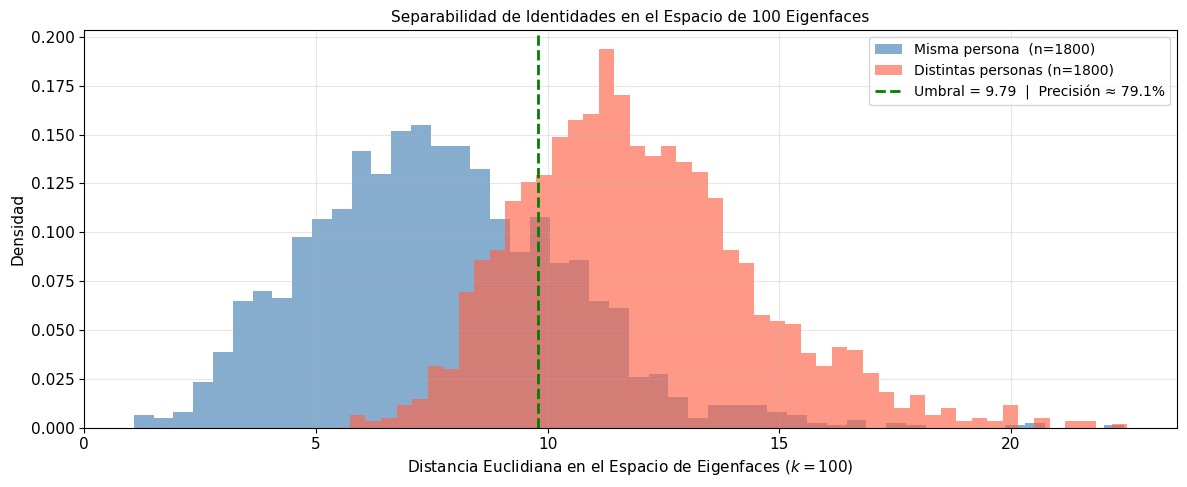


📊 Resultados con umbral = 9.791:
   Verdaderos Positivos (misma persona, bien clasificada): 1416/1800
   Verdaderos Negativos (distintas, bien clasificadas)   : 1433/1800
   Precisión total                                       : 79.1%


In [15]:
# ══════════════════════════════════════════════════════════════
#  DISTRIBUCIÓN COMPLETA DE DISTANCIAS (todos los pares)
# ══════════════════════════════════════════════════════════════
print("⏳ Calculando distancias para todos los pares (puede tardar ~15 s)...")

# Representaciones de todas las imágenes de una vez (vectorización)
reps_todas = (faces - media_facial) @ Vk.T    # 400 × k_rep

dist_mismo_arr    = []
dist_distinto_arr = []

for p in range(40):
    idxs_p = np.where(labels == p)[0]
    # Pares misma persona
    for ii in range(len(idxs_p)):
        for jj in range(ii+1, len(idxs_p)):
            d = np.linalg.norm(reps_todas[idxs_p[ii]] - reps_todas[idxs_p[jj]])
            dist_mismo_arr.append(d)

# Pares de personas distintas (muestreo aleatorio balanceado)
np.random.seed(123)
n_pares = len(dist_mismo_arr)
for _ in range(n_pares):
    p1, p2 = np.random.choice(40, 2, replace=False)
    i1 = np.random.choice(np.where(labels == p1)[0])
    i2 = np.random.choice(np.where(labels == p2)[0])
    dist_distinto_arr.append(np.linalg.norm(reps_todas[i1] - reps_todas[i2]))

umbral_medio = (np.mean(dist_mismo_arr) + np.mean(dist_distinto_arr)) / 2

# Precisión simple con umbral de distancia media
vp = sum(d < umbral_medio for d in dist_mismo_arr)   # misma persona correctamente
vn = sum(d > umbral_medio for d in dist_distinto_arr) # distintas personas correctamente
precision = (vp + vn) / (2 * n_pares) * 100

# ── Histograma ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(dist_mismo_arr,    bins=50, alpha=0.65, color='steelblue',
        label=f'Misma persona  (n={len(dist_mismo_arr)})', density=True)
ax.hist(dist_distinto_arr, bins=50, alpha=0.65, color='tomato',
        label=f'Distintas personas (n={len(dist_distinto_arr)})', density=True)
ax.axvline(umbral_medio, color='green', linewidth=2, linestyle='--',
           label=f'Umbral = {umbral_medio:.2f}  |  Precisión ≈ {precision:.1f}%')
ax.set_xlabel("Distancia Euclidiana en el Espacio de Eigenfaces ($k = 100$)")
ax.set_ylabel("Densidad")
ax.set_title(f"Separabilidad de Identidades en el Espacio de {k_rep} Eigenfaces")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Resultados con umbral = {umbral_medio:.3f}:")
print(f"   Verdaderos Positivos (misma persona, bien clasificada): {vp}/{n_pares}")
print(f"   Verdaderos Negativos (distintas, bien clasificadas)   : {vn}/{n_pares}")
print(f"   Precisión total                                       : {precision:.1f}%")

In [29]:
# ══════════════════════════════════════════════════════════════
#  EFECTO DE k EN LA PRECISIÓN DEL CLASIFICADOR
# ══════════════════════════════════════════════════════════════
print("⏳ Evaluando precisión para distintos valores de k...\n")

# Subconjunto de pares para velocidad
pares_mismo_sub    = list(zip(
    [np.where(labels==p)[0][i] for p in range(40) for i in range(4)],
    [np.where(labels==p)[0][i+1] for p in range(40) for i in range(4)]
))
pares_distinto_sub = []
np.random.seed(42)
for _ in range(len(pares_mismo_sub)):
    p1, p2 = np.random.choice(40, 2, replace=False)
    pares_distinto_sub.append((
        np.random.choice(np.where(labels==p1)[0]),
        np.random.choice(np.where(labels==p2)[0])
    ))

ks_eval = [5, 10, 20, 50, 100, 200, 400]

print(f"{'k':>5} | {'μ_misma':>9} | {'μ_distinta':>11} | {'Separación (σ)':>15} | {'Precisión':>10}")
print("─" * 60)

for k in ks_eval:
    Vk_e = eigenvectores[:k]
    reps = (faces - media_facial) @ Vk_e.T

    dm = [np.linalg.norm(reps[i] - reps[j]) for i,j in pares_mismo_sub]
    dd = [np.linalg.norm(reps[i] - reps[j]) for i,j in pares_distinto_sub]

    mu_m, mu_d = np.mean(dm), np.mean(dd)
    sep = (mu_d - mu_m) / ((np.std(dm) + np.std(dd)) / 2 + 1e-8)
    thr = (mu_m + mu_d) / 2
    prec = (sum(d < thr for d in dm) + sum(d > thr for d in dd)) / (2*len(dm)) * 100

    print(f"{k:>5} | {mu_m:>9.3f} | {mu_d:>11.3f} | {sep:>15.3f} | {prec:>9.1f}%")

⏳ Evaluando precisión para distintos valores de k...

    k |   μ_misma |  μ_distinta |  Separación (σ) |  Precisión
────────────────────────────────────────────────────────────
    5 |     4.273 |       8.682 |           1.527 |      76.6%
   10 |     4.964 |       9.751 |           1.722 |      79.7%
   20 |     5.655 |      10.631 |           1.845 |      81.6%
   50 |     6.600 |      11.492 |           1.851 |      81.2%
  100 |     7.227 |      11.919 |           1.798 |      80.6%
  200 |     7.725 |      12.213 |           1.762 |      80.9%
  400 |     8.000 |      12.353 |           1.765 |      80.9%


### ✏️ Preguntas 5 — Verificación de Identidad

**P5.1** El clasificador compara distancias euclidianas $\|\boldsymbol{\alpha}_1 - \boldsymbol{\alpha}_2\|_2$ en $\mathbb{R}^k$. ¿Esta distancia en el espacio de eigenfaces es igual a la distancia euclidiana en el espacio original $\mathbb{R}^{4096}$?  

Demuestren o refuten: dado que $V_k$ es una isometría parcial, ¿qué relación exacta existe entre $\|V_k\tilde{\mathbf{x}}_1 - V_k\tilde{\mathbf{x}}_2\|$ y $\|\tilde{\mathbf{x}}_1 - \tilde{\mathbf{x}}_2\|$?

> *Respuesta:*

---

**P5.2** El histograma muestra que las distribuciones de distancias se **solapan parcialmente** — hay errores inevitables.  

a) Definan **Falso Positivo** y **Falso Negativo** en este contexto de reconocimiento facial.  
b) En un sistema de **seguridad de alta seguridad** (acceso a zona restringida), ¿cuál de los dos errores es más costoso? ¿Y en la función "desbloqueo de teléfono"?  
c) ¿Cómo ajustarían el umbral en cada caso? ¿Qué compensación (trade-off) implica esto?

> *Respuesta:*

---

**P5.3** Observen la tabla de precisión para distintos $k$:  
a) ¿Cuál parece ser el $k$ "óptimo"? ¿Por qué la precisión **empeora** para $k$ muy grande ($k = 400$)?  
b) Con $k$ muy pequeño (e.g., $k=5$), ¿qué información de identidad se pierde? Conéctenlo con el espectro de eigenvalores.

> *Respuesta:*

---
## 🧠 Preguntas de Síntesis — Cierre de Actividad

Estas preguntas integran **todos** los conceptos trabajados. Discútanlas cuidadosamente antes de escribir.

---

**PS.1 — El pipeline completo en términos algebraicos**

Describan el pipeline completo `imagen → representación → reconocimiento` en términos algebraicos precisos, mencionando **explícitamente**:

- El espacio vectorial donde viven los datos y su dimensión
- La transformación lineal $T: \mathbb{R}^{4096} \to \mathbb{R}^k$ y su representación matricial
- Por qué los eigenvectores de $C$ forman la "base óptima" (mencionen el criterio de optimización)
- Cómo los eigenvalores determinan cuántos eigenvectores conservar
- La conexión entre el Teorema Espectral y la validez de toda la construcción

> *Respuesta (mínimo 150 palabras):*

---

**PS.2 — Teorema Espectral: consecuencias concretas**

La matriz de covarianza $C$ es **simétrica semidefinida positiva**. Expliquen cada consecuencia del Teorema Espectral en el contexto específico de esta actividad:

a) $C$ es diagonalizable como $C = V\Lambda V^T$ → ¿qué significa esto para cambiar de "base de píxeles" a "base de eigenfaces"?

b) Los eigenvectores forman una **base ortonormal** de $\mathbb{R}^{4096}$ → ¿por qué esto garantiza que **cualquier** rostro puede reconstruirse perfectamente con $k = 4096$ eigenfaces?

c) Los eigenvalores $\lambda_i \geq 0$ → ¿qué garantiza esto sobre la "energía" de cada componente? ¿Podría un eigenvalor negativo tener interpretación física en este contexto?

> *Respuesta:*

---

**PS.3 — Reflexión crítica: sesgos y limitaciones**

El dataset Olivetti fue creado en 1992 y presenta sesgos demográficos (mayoría de género masculino, poca diversidad étnica). Usando los conceptos de esta actividad:

a) Los eigenfaces capturan la **varianza** del conjunto de entrenamiento. Si el dataset tiene poca diversidad, ¿qué tipos de variación facial "aprenderán" los eigenfaces? ¿Qué variaciones serán ignoradas?

b) ¿Cómo afecta esto a la **precisión del clasificador** cuando se usa con personas de grupos subrepresentados? Justifiquen geométricamente (piensen en proyecciones y distancias).

c) ¿Cómo mejorarían el dataset para que el sistema sea más equitativo? ¿Qué implicaría esto para los eigenfaces?

> *Respuesta:*

---

**PS.4 — Más allá de la linealidad (pregunta de extensión)**

El método de eigenfaces asume que el "espacio de rostros" puede aproximarse bien por un **subespacio lineal** de $\mathbb{R}^{4096}$. En la práctica, esto tiene limitaciones:

a) ¿Qué fenómeno concreto (piensen en poses extremas, expresiones muy variadas, iluminación lateral) hace que los rostros NO vivan en un subespacio lineal?

b) Los **autoencoders** de redes neuronales son una generalización no lineal del PCA: el encoder aprende una función no lineal $f: \mathbb{R}^{4096} \to \mathbb{R}^k$ y el decoder aprende $g: \mathbb{R}^k \to \mathbb{R}^{4096}$. ¿Cuál sería la analogía del "subespacio de eigenfaces" en este caso? ¿Qué lo hace más poderoso y qué se pierde respecto al PCA?

> *Respuesta:*

---
## 📋 Rúbrica de Evaluación

| Sección | Preguntas | Puntos |
|---|---|:---:|
| **S1** — Imágenes como vectores | P1.1, P1.2, P1.3 | 15 |
| **S2** — Transformaciones lineales | P2.1, P2.2, P2.3, P2.4 | 20 |
| **S3** — Covarianza y eigenfaces | P3.1, P3.2, P3.3, P3.4, P3.5 | 25 |
| **S4** — Reconstrucción | P4.1, P4.2, P4.3, P4.4 | 20 |
| **S5** — Verificación de identidad | P5.1, P5.2, P5.3 | 10 |
| **Síntesis** | PS.1 – PS.4 | 10 |
| **Total** | | **100** |

---

**Criterios de calidad transversales:**

- ✅ Usar terminología matemática precisa (subespacio, base, proyección ortogonal, etc.)
- ✅ Justificar con argumentos, no solo afirmar
- ✅ Conectar los resultados numéricos/visuales con la teoría
- ✅ En síntesis: mostrar comprensión integrada, no resumen descriptivo
- ❌ "El resultado es X" sin justificación → puntaje parcial
- ❌ Copiar definiciones del libro sin conectarlas al contexto → sin puntaje

---

*Actividad diseñada para el curso de Álgebra Lineal | 2026*  
*Datos: Olivetti Faces Dataset — AT&T Laboratories Cambridge (1992–1994)*  
*Método: Turk & Pentland, "Eigenfaces for Recognition", Journal of Cognitive Neuroscience, 1991*